# Laboratorium 3 — Uczenie ze wzmocnieniem: Q-learning vs SARSA w środowisku Cliff Walking

**Autor:** Szymon Drapiński
**Data:** 12.06.2026
**Przedmiot:** Zaawansowane metody sztucznej inteligencji

Raport przedstawia porównanie dwóch klasycznych algorytmów uczenia ze wzmocnieniem — **Q-learning** oraz **SARSA** —
w środowisku **Cliff Walking** (Sutton & Barto, *Reinforcement Learning: An Introduction*).
Wykorzystano dostarczony plik `3_RL_cliffwalking.py`, z którego importowane są: środowisko, funkcje uczące,
funkcja ewaluacji oraz funkcje generujące wykresy. Wykonano **eksperyment bazowy (E1)** oraz **cztery własne
eksperymenty (E2–E5)** ze zmianą pojedynczych parametrów w sposób kontrolowany.

## 1. Wstęp teoretyczny

### 1.1. Czym jest uczenie ze wzmocnieniem (RL)?

Uczenie ze wzmocnieniem (ang. *Reinforcement Learning*) to paradygmat uczenia maszynowego, w którym **agent**
uczy się podejmować decyzje poprzez interakcję ze **środowiskiem**. W każdym kroku agent:

1. obserwuje **stan** środowiska $s_t$,
2. wybiera **akcję** $a_t$ zgodnie ze swoją **polityką** $\pi$,
3. otrzymuje **nagrodę** $r_{t+1}$ i przechodzi do nowego stanu $s_{t+1}$.

Celem agenta jest maksymalizacja **skumulowanej, zdyskontowanej nagrody** $G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$,
gdzie $\gamma \in [0,1]$ to współczynnik dyskontowania. Agent nie zna z góry modelu środowiska — uczy się metodą
prób i błędów, balansując między **eksploracją** (próbowanie nowych akcji) a **eksploatacją** (wybieranie akcji
uznawanych za najlepsze). W tym laboratorium balans ten realizuje strategia **ε-zachłanna** (*epsilon-greedy*):
z prawdopodobieństwem ε agent wybiera akcję losową, w przeciwnym razie akcję o najwyższej wartości Q.
Parametr ε maleje wykładniczo w trakcie uczenia (`epsilon_decay`), aż do wartości minimalnej `epsilon_min`.

Oba badane algorytmy uczą się **funkcji wartości akcji** $Q(s, a)$ — oczekiwanej skumulowanej nagrody po wykonaniu
akcji $a$ w stanie $s$ — metodą różnic czasowych (*Temporal Difference, TD*).

### 1.2. Q-learning (off-policy)

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]$$

Q-learning jest algorytmem **off-policy**: do aktualizacji używa wartości **najlepszej możliwej** akcji w następnym
stanie ($\max_{a'} Q$), niezależnie od tego, jaką akcję agent faktycznie wykona. Uczy się więc polityki
**optymalnej (zachłannej)**, nawet jeśli w trakcie treningu zachowuje się eksploracyjnie.

### 1.3. SARSA (on-policy)

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]$$

SARSA (nazwa od piątki $s, a, r, s', a'$) jest algorytmem **on-policy**: do aktualizacji używa wartości akcji
$a_{t+1}$, którą agent **faktycznie wybierze** (łącznie z losowymi ruchami eksploracyjnymi). Uczy się więc wartości
polityki, którą realnie prowadzi — wliczając ryzyko wynikające z eksploracji.

### 1.4. Kluczowa różnica w kontekście Cliff Walking

| Cecha | Q-learning | SARSA |
|---|---|---|
| Typ | off-policy | on-policy |
| Cel TD | $\max_{a'} Q(s', a')$ | $Q(s', a')$ dla faktycznej akcji |
| Czego się uczy | polityki optymalnej | polityki aktualnie realizowanej |
| Zachowanie przy klifie | trasa **optymalna, ale ryzykowna** (tuż przy klifie) | trasa **bezpieczniejsza** (dalej od klifu) |
| Nagrody w trakcie treningu | niższe (częste upadki przez eksplorację) | wyższe (unika okolic klifu) |

Q-learning ignoruje fakt, że ε-zachłanna eksploracja może zepchnąć agenta z klifu, więc wycenia trasę przy samej
krawędzi jako najlepszą. SARSA „wlicza" ryzyko losowego kroku w przepaść do wartości stanów przy krawędzi, więc
preferuje dłuższą, bezpieczniejszą trasę.

## 2. Opis środowiska i kodowanie stanów oraz akcji

**Cliff Walking** to deterministyczna siatka **4 × 12** (48 pól):

- `S` — start: lewy dolny róg, pozycja `(3, 0)`,
- `G` — cel: prawy dolny róg, pozycja `(3, 11)`,
- `C` — klif: cała dolna krawędź między S a G, pola `(3, 1)`–`(3, 10)`.

**Nagrody** (parametry `Config`):

| Zdarzenie | Nagroda | Skutek |
|---|---|---|
| zwykły krok | `step_penalty = -1` | przejście na sąsiednie pole |
| wejście na klif | `cliff_penalty = -100` | **powrót na start** (epizod trwa dalej) |
| osiągnięcie celu | `goal_reward = -1` | **koniec epizodu** |

Kara −1 za każdy krok wymusza szukanie **jak najkrótszej** trasy. Optymalna (ryzykowna) trasa tuż przy klifie ma
13 kroków → nagroda epizodu **−13**; bezpieczna trasa górą jest dłuższa (np. 15 kroków → **−15**).

**Kodowanie stanów:** stan to pozycja agenta `(wiersz, kolumna)` mapowana na pojedynczy indeks
`index = wiersz * 12 + kolumna` (0–47). Tablica Q ma wymiar **48 × 4**.

**Kodowanie akcji:** 4 akcje deterministyczne — `0: ↑ góra`, `1: → prawo`, `2: ↓ dół`, `3: ← lewo`.
Ruch poza planszę jest „przycinany" do krawędzi (agent zostaje na miejscu, ale ponosi karę kroku).

**Ewaluacja polityki:** po treningu polityka jest oceniana **zachłannie** (ε = 0, zawsze `argmax Q`) przez 200
epizodów — mierzymy średnią nagrodę, odchylenie standardowe, success rate i średnią liczbę kroków.

In [1]:
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Plik laboratorium zaczyna się cyfrą, więc ładujemy go przez importlib
spec = importlib.util.spec_from_file_location("rl_lab", Path("3_RL_cliffwalking.py").resolve())
rl = importlib.util.module_from_spec(spec)
sys.modules["rl_lab"] = rl  # wymagane przez @dataclass przy adnotacjach z __future__
spec.loader.exec_module(rl)

OUT = Path("wyniki_raport")
OUT.mkdir(exist_ok=True)

env_demo = rl.CliffWalkingEnv()
print("Mapa środowiska (S=start, G=cel, C=klif):\n")
print(env_demo.render_ascii())
print("\nPrzykłady kodowania stanów:")
for pos in [(3, 0), (0, 0), (3, 11), (1, 5)]:
    print(f"  pozycja {pos} -> indeks stanu {env_demo.state_to_index(pos)}")
print(f"\nLiczba stanów: {env_demo.n_states}, liczba akcji: {env_demo.n_actions}")
print("Akcje:", {k: v for k, v in rl.CliffWalkingEnv.ACTION_NAMES.items()})

Mapa środowiska (S=start, G=cel, C=klif):

 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 S  C  C  C  C  C  C  C  C  C  C  G 

Przykłady kodowania stanów:
  pozycja (3, 0) -> indeks stanu 36
  pozycja (0, 0) -> indeks stanu 0
  pozycja (3, 11) -> indeks stanu 47
  pozycja (1, 5) -> indeks stanu 17

Liczba stanów: 48, liczba akcji: 4
Akcje: {0: '↑', 1: '→', 2: '↓', 3: '←'}


## 3. Metodologia eksperymentów

Każdy eksperyment uruchamia **oba algorytmy na identycznych ustawieniach** (ten sam `Config`, to samo ziarno
losowe `seed = 42`), co pozwala na uczciwe porównanie. Funkcja pomocnicza `run_experiment`:

1. tworzy środowisko i konfigurację z nadpisanymi parametrami,
2. trenuje Q-learning i SARSA (`train_q_learning`, `train_sarsa` z pliku laboratorium),
3. ewaluuje obie wytrenowane polityki zachłannie (`evaluate_policy`, 200 epizodów),
4. dodatkowo liczy **średnią i odchylenie nagród z ostatnich 100 epizodów treningu** — miara tego, jak algorytm
   radzi sobie *w trakcie* uczenia (z eksploracją), oraz miara stabilności.

### Plan eksperymentów

| Eksperyment | Zmieniany parametr | Wartość | Hipoteza |
|---|---|---|---|
| **E1** | — (baza) | `alpha=0.10, gamma=0.95, eps_decay=0.995, episodes=800, cliff=-100` | punkt odniesienia |
| **E2** | `alpha` ↑ | `alpha = 0.50` | szybsza zbieżność, ale mniejsza stabilność |
| **E3** | `epsilon_decay` ↑ (wolniejszy zanik ε) | `eps_decay = 0.999` | dłuższa eksploracja → niższe nagrody treningowe, możliwa lepsza polityka |
| **E4** | `cliff_penalty` ↓ (słabsza kara) | `cliff_penalty = -10` | klif mniej „straszny" → SARSA przestanie omijać go szerokim łukiem |
| **E5** | `episodes` ↑ | `episodes = 2000` | sprawdzenie efektu malejących korzyści |

In [2]:
def run_experiment(name, **overrides):
    """Trenuje Q-learning i SARSA na wspólnej konfiguracji i zbiera metryki."""
    cfg = rl.Config(**overrides)
    env = rl.CliffWalkingEnv(
        rows=cfg.rows, cols=cfg.cols,
        step_penalty=cfg.step_penalty,
        cliff_penalty=cfg.cliff_penalty,
        goal_reward=cfg.goal_reward,
    )
    results = {
        "Q-learning": rl.train_q_learning(env, cfg),
        "SARSA": rl.train_sarsa(env, cfg),
    }
    metrics = {}
    for algo, res in results.items():
        m = rl.evaluate_policy(env, res["q_table"], episodes=cfg.eval_episodes, max_steps=cfg.max_steps)
        last100 = np.array(res["episode_rewards"][-100:])
        m["train_mean_last100"] = float(last100.mean())
        m["train_std_last100"] = float(last100.std())
        metrics[algo] = m
    return {"name": name, "cfg": cfg, "env": env, "results": results, "metrics": metrics}


def plot_learning(exp, window=25):
    """Krzywe uczenia (średnia krocząca nagród epizodów) dla obu algorytmów."""
    plt.figure(figsize=(10, 5))
    for algo, res in exp["results"].items():
        ma = rl.moving_average(res["episode_rewards"], window)
        plt.plot(ma, label=f"{algo} (śr. krocząca {window})")
    plt.title(f"Przebieg uczenia — {exp['name']}")
    plt.xlabel("Epizod")
    plt.ylabel("Skumulowana nagroda w epizodzie")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / f"krzywa_{exp['name'].split()[0]}.png", dpi=150)
    plt.show()


def show_policies(exp):
    """Polityki zachłanne obu algorytmów: ASCII + wykres (funkcje z pliku laboratorium)."""
    for algo, res in exp["results"].items():
        policy = rl.derive_greedy_policy(res["q_table"])
        print(f"--- Polityka zachłanna: {algo} ({exp['name']}) ---")
        print(exp["env"].render_ascii(policy))
        print()
        fname = OUT / f"polityka_{exp['name'].split()[0]}_{algo.replace('-', '_')}.png"
        rl.plot_policy(exp["env"], res["q_table"], f"Polityka zachłanna — {algo} ({exp['name']})", fname)
        display(Image(filename=str(fname)))


def print_metrics(exp):
    for algo, m in exp["metrics"].items():
        print(f"{algo:11s} | eval: śr. nagroda {m['mean_reward']:8.2f} (std {m['std_reward']:.2f}), "
              f"śr. kroki {m['mean_steps']:6.2f}, success {m['success_rate']:.0%} | "
              f"trening (ost. 100 ep.): śr. {m['train_mean_last100']:8.2f}, std {m['train_std_last100']:.2f}")


def metrics_rows(exp, wniosek=""):
    rows = []
    cfg = exp["cfg"]
    for algo, m in exp["metrics"].items():
        rows.append({
            "Eksperyment": exp["name"].split()[0],
            "Algorytm": algo,
            "alpha": cfg.alpha,
            "gamma": cfg.gamma,
            "eps_decay": cfg.epsilon_decay,
            "episodes": cfg.episodes,
            "cliff_penalty": cfg.cliff_penalty,
            "Śr. nagroda (eval)": round(m["mean_reward"], 2),
            "Śr. kroki (eval)": round(m["mean_steps"], 2),
            "Śr. nagroda trening (ost.100)": round(m["train_mean_last100"], 2),
            "Std trening (ost.100)": round(m["train_std_last100"], 2),
            "Wniosek": wniosek,
        })
    return rows

all_rows = []

## 4. Eksperyment E1 — konfiguracja bazowa

Domyślne parametry z pliku laboratorium: `alpha=0.10`, `gamma=0.95`, `epsilon: 1.0 → 0.05` z `decay=0.995`,
`episodes=800`, `cliff_penalty=-100`. To odtworzenie wyników referencyjnych (`wyniki_rl/`, `wyniki_referencyjne/`).

Q-learning  | eval: śr. nagroda   -13.00 (std 0.00), śr. kroki  13.00, success 100% | trening (ost. 100 ep.): śr.   -25.61, std 33.86
SARSA       | eval: śr. nagroda   -17.00 (std 0.00), śr. kroki  17.00, success 100% | trening (ost. 100 ep.): śr.   -18.87, std 9.95


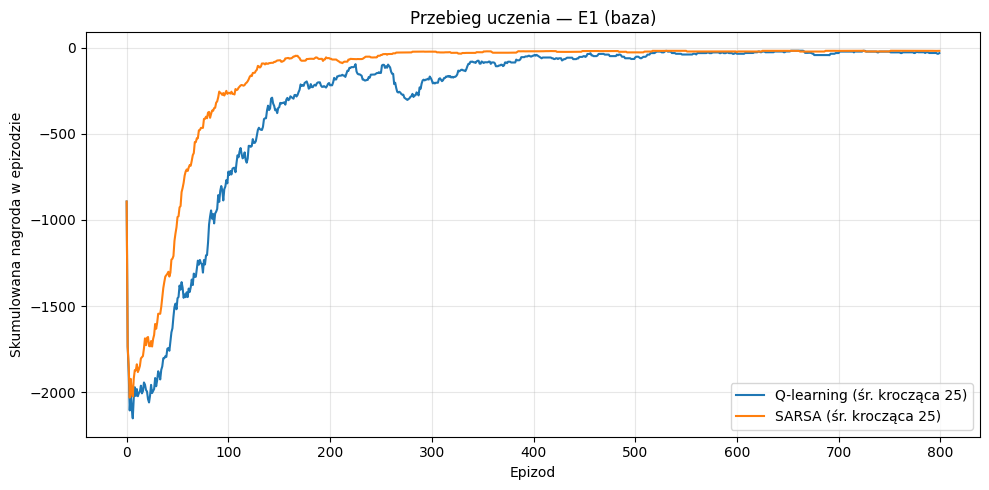

In [3]:
e1 = run_experiment("E1 (baza)")
print_metrics(e1)
plot_learning(e1)

--- Polityka zachłanna: Q-learning (E1 (baza)) ---
 ←  ←  →  ↓  ←  ↓  →  →  ↓  ↓  →  ↓ 
 →  ↓  →  ←  →  →  →  ↓  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



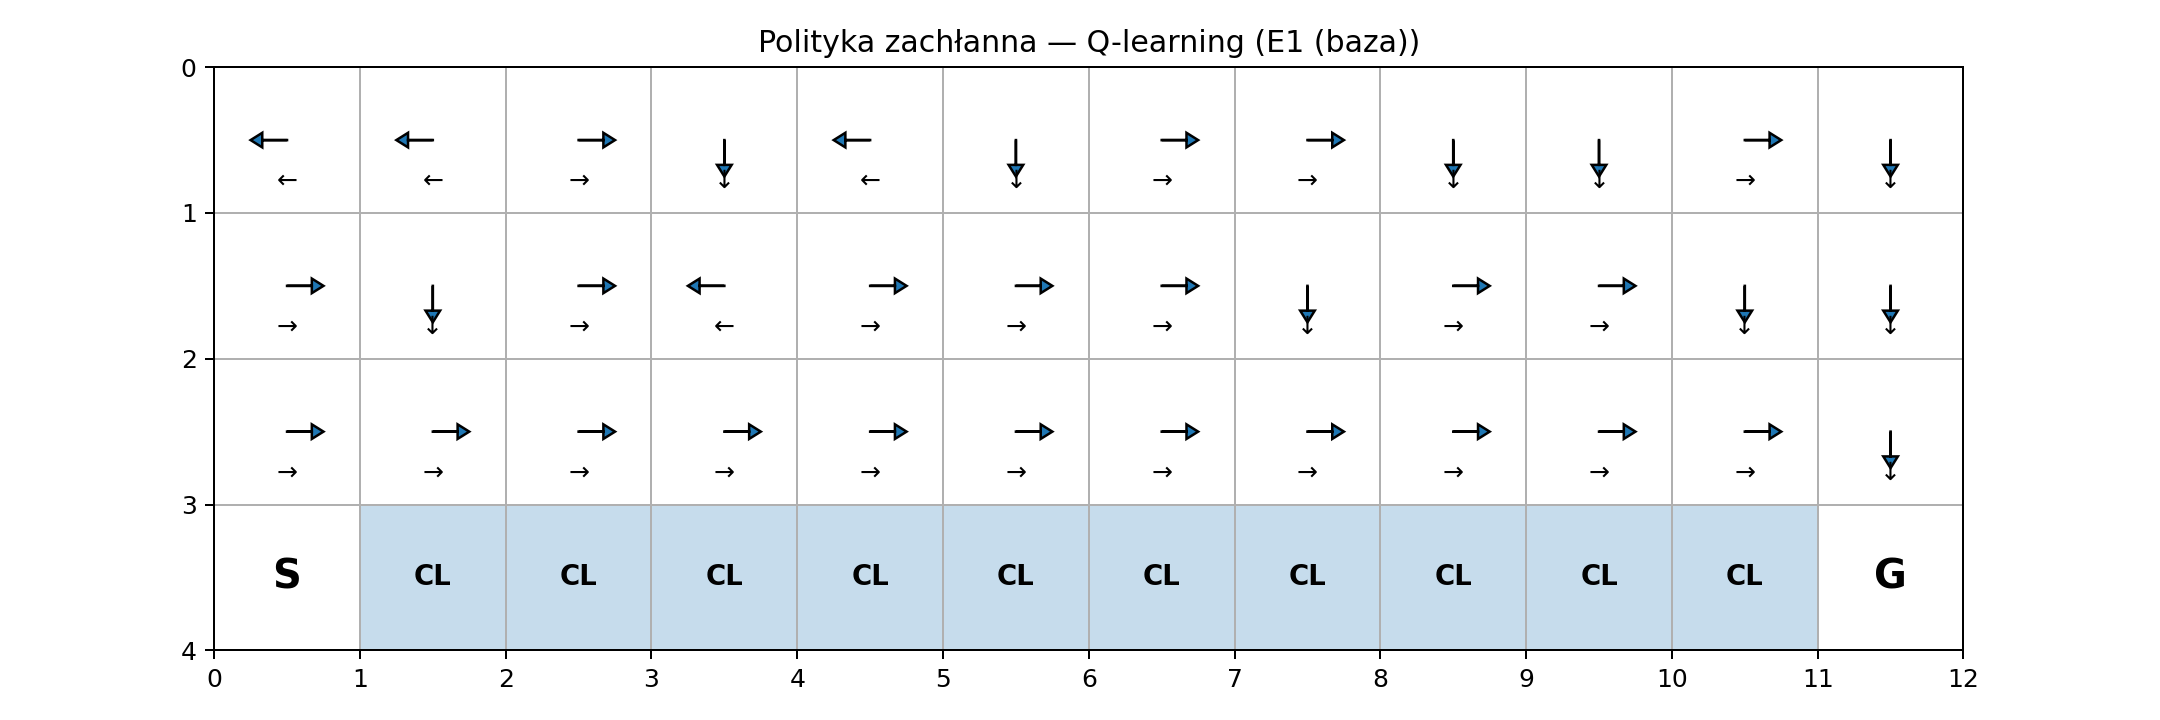

--- Polityka zachłanna: SARSA (E1 (baza)) ---
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



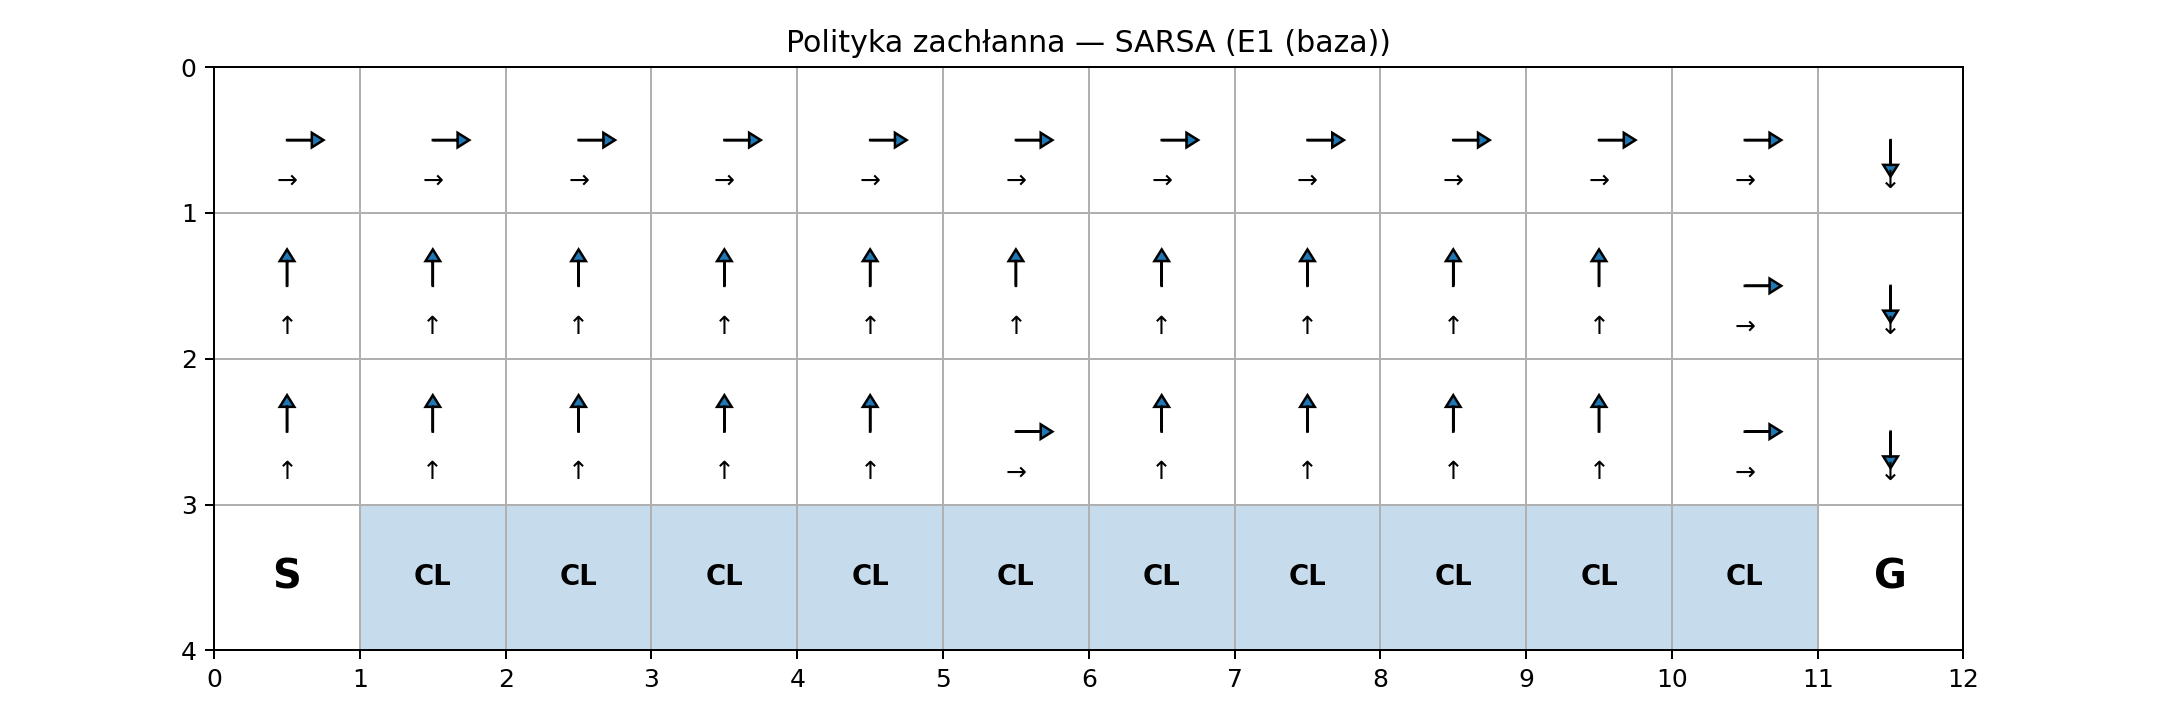

In [4]:
show_policies(e1)
all_rows += metrics_rows(e1, "Q-learning: trasa przy klifie; SARSA: trasa bezpieczna, wyższe nagrody w treningu")

### Interpretacja E1

- **Krzywe uczenia:** w pierwszych ~100 epizodach oba algorytmy zbierają bardzo niskie nagrody (wysokie ε → częste
  losowe wpadanie do klifu). W miarę zaniku ε krzywe szybko rosną i stabilizują się około epizodu 300–400.
- **W trakcie treningu SARSA osiąga wyższą średnią nagrodę** niż Q-learning (ostatnie 100 epizodów:
  **−18.9 vs −25.6**) i jest wyraźnie stabilniejsza (std **10.0 vs 33.9**). To klasyczny efekt on-policy:
  SARSA wycenia pola przy klifie nisko (bo eksploracja bywa tam kosztowna) i trzyma się od niego z daleka,
  więc losowy ruch rzadko kończy się u niej upadkiem.
- **Polityki finalne:** Q-learning wybiera optymalną trasę **tuż przy klifie** — 13 kroków, nagroda **−13**.
  SARSA wspina się na **najwyższy wiersz planszy** i idzie nim do celu — 17 kroków, nagroda **−17**.
  W ewaluacji zachłannej (ε=0, środowisko deterministyczne → std=0) obie polityki mają 100% sukcesów,
  ale Q-learning wygrywa, bo jego trasa jest krótsza.

## 5. Eksperyment E2 — zwiększenie szybkości uczenia: `alpha = 0.50`

Pytanie pomocnicze: *jak wpływa zwiększenie alpha na szybkość i stabilność uczenia?*
Pięciokrotnie większy krok aktualizacji TD — wartości Q zmieniają się gwałtowniej.

Q-learning  | eval: śr. nagroda   -13.00 (std 0.00), śr. kroki  13.00, success 100% | trening (ost. 100 ep.): śr.   -32.12, std 43.36
SARSA       | eval: śr. nagroda  -200.00 (std 0.00), śr. kroki 200.00, success 0% | trening (ost. 100 ep.): śr.  -200.99, std 9.85


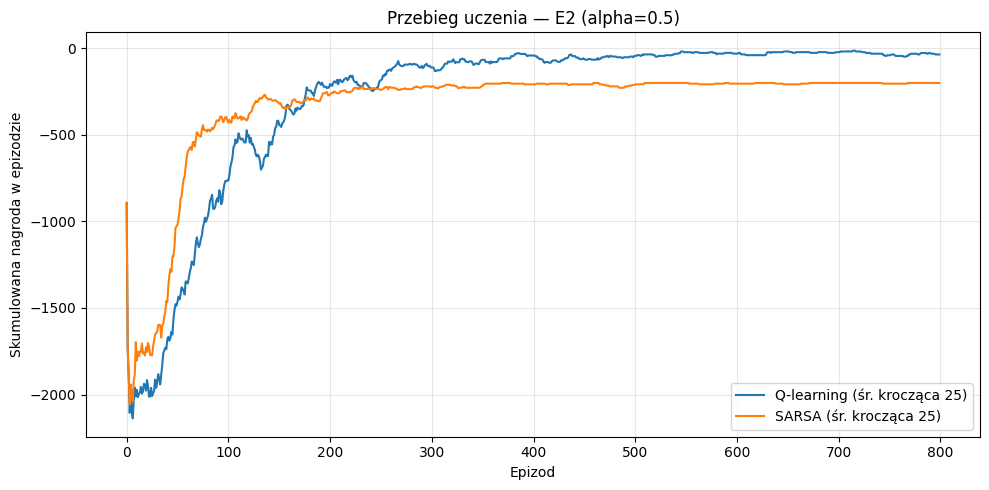

In [5]:
e2 = run_experiment("E2 (alpha=0.5)", alpha=0.50)
print_metrics(e2)
plot_learning(e2)

--- Polityka zachłanna: Q-learning (E2 (alpha=0.5)) ---
 ↓  →  →  ↓  →  →  →  ↓  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



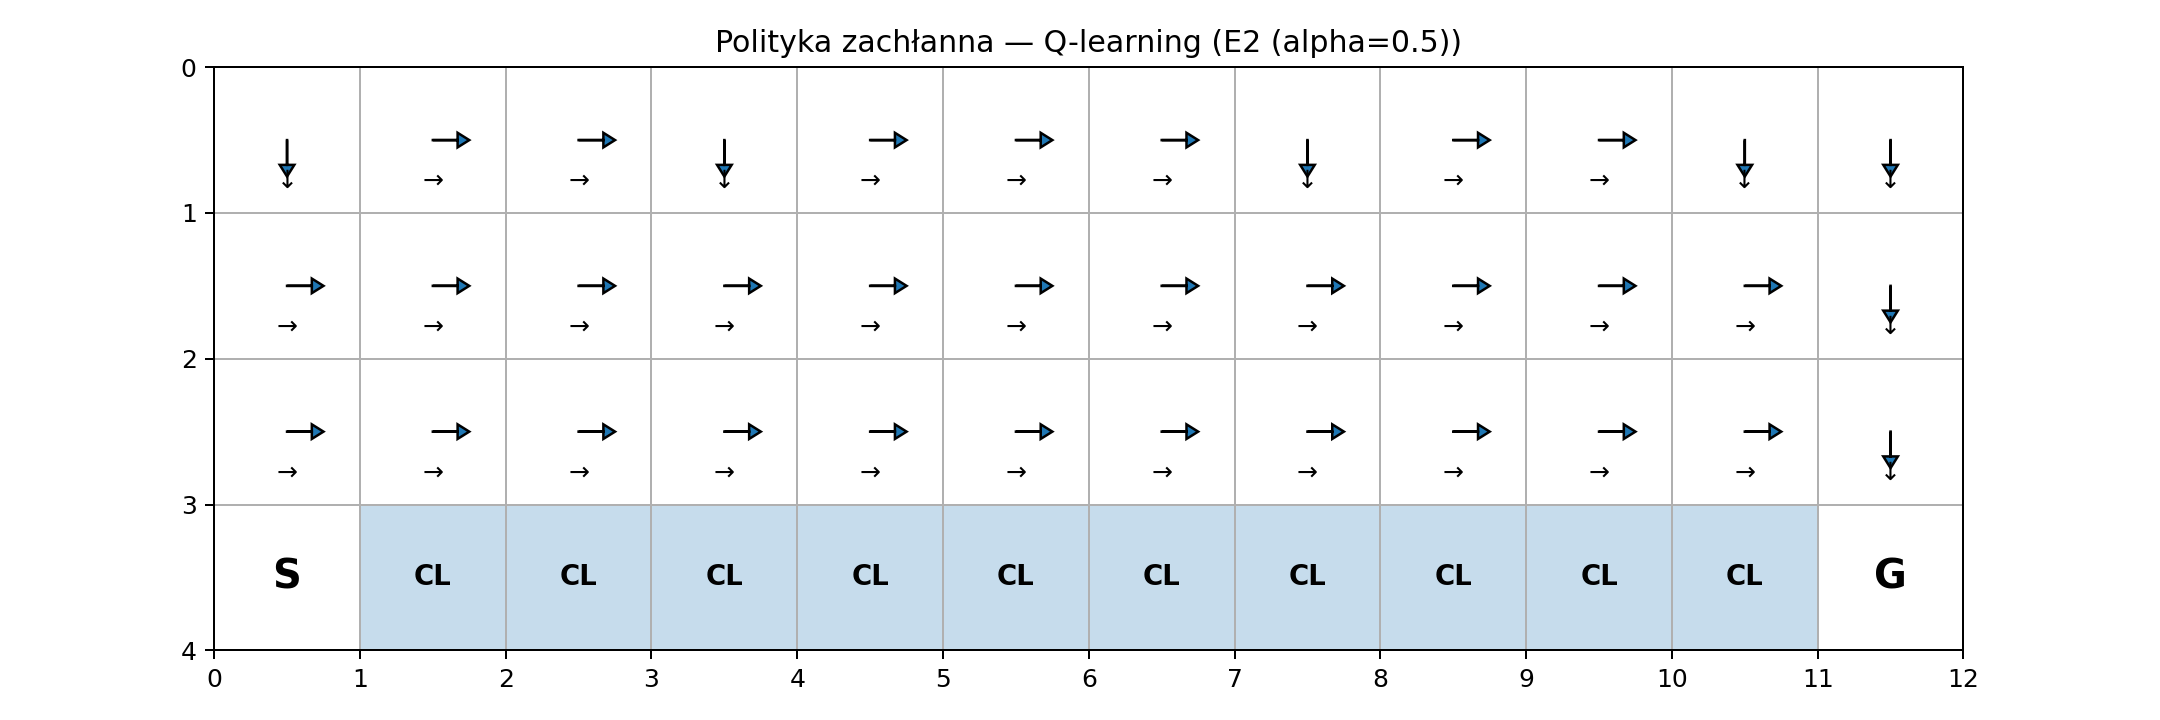

--- Polityka zachłanna: SARSA (E2 (alpha=0.5)) ---
 ←  ←  ←  ←  ←  →  ↓  →  →  →  ↑  ↓ 
 ↑  ←  ←  ←  ↑  ↑  →  →  →  ↓  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ←  ↑  ↑  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



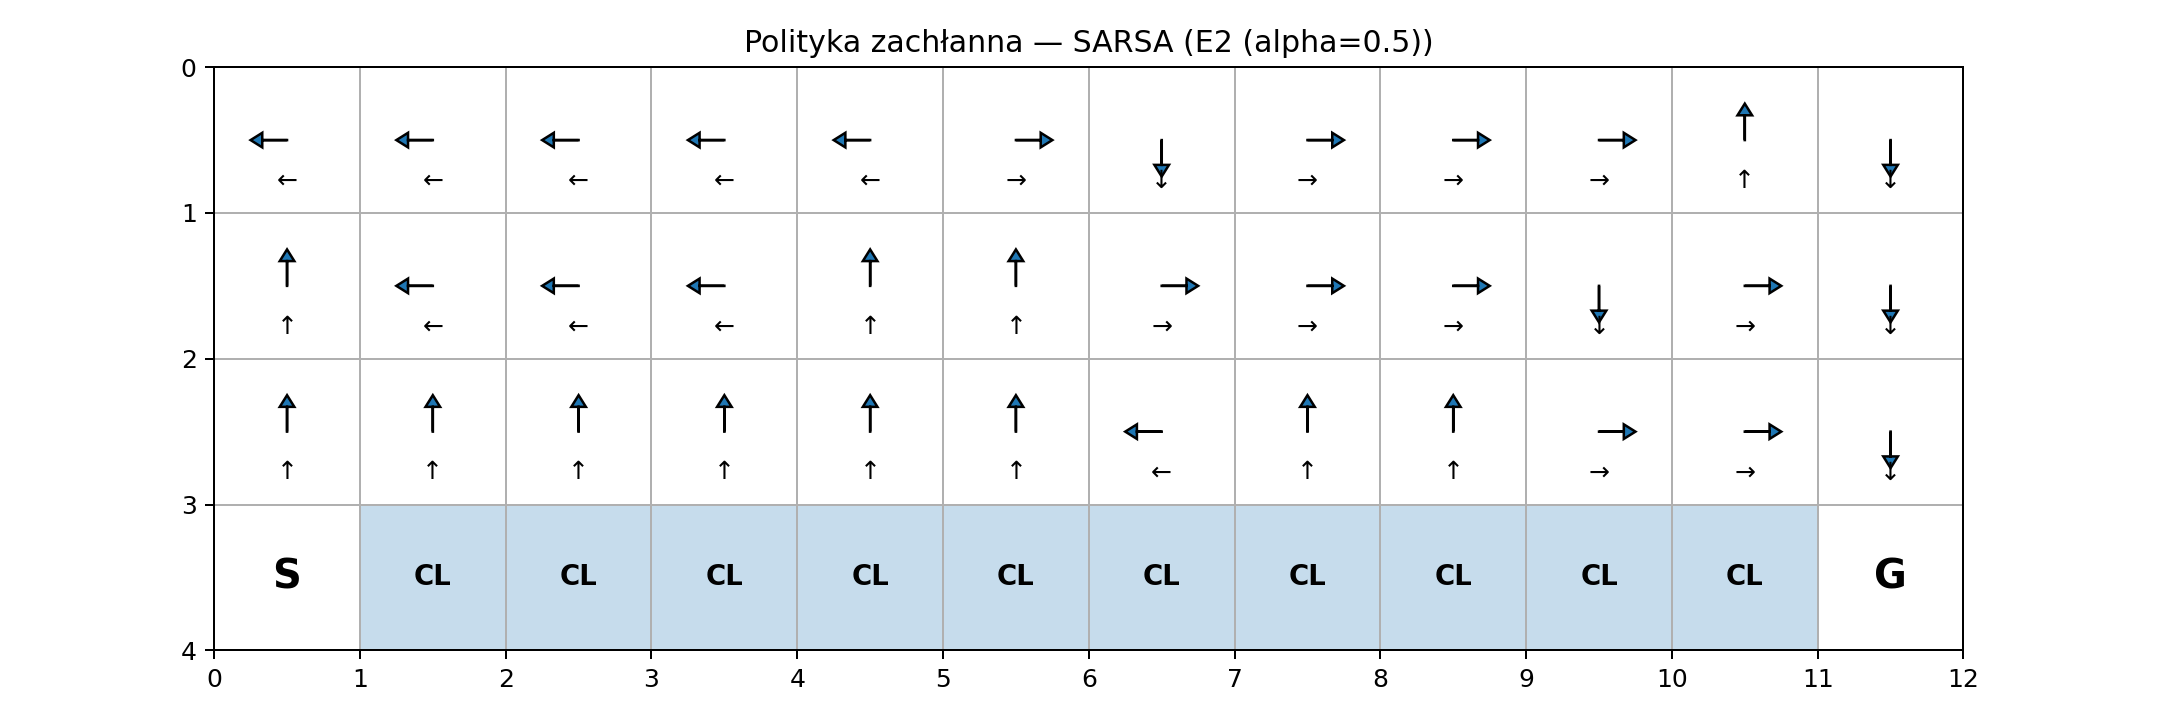

In [6]:
show_policies(e2)
all_rows += metrics_rows(e2, "Q-learning nadal optymalny; SARSA niestabilna — polityka finalna nie dochodzi do celu (0%)")

### Interpretacja E2

- Wyższa `alpha` daje **szybszy początkowy wzrost** krzywej uczenia — informacja o karach propaguje się po
  tablicy Q w mniejszej liczbie epizodów. Ceną jest większa wariancja: pojedynczy upadek mocno nadpisuje
  wartości Q.
- **Q-learning okazał się odporny**: jego cel TD ($\max_{a'} Q$) jest stabilny, więc mimo dużego kroku
  nadal znajduje optymalną trasę przy klifie (eval **−13**, 100% sukcesów).
- **SARSA przy `alpha=0.5` się rozsypała**: jej cel TD zależy od *faktycznie wylosowanej* następnej akcji,
  więc duży krok uczenia wzmacnia szum eksploracji. Finalna polityka zachłanna jest niespójna (strzałki ← i ↑
  w lewej części planszy tworzą pętle) i **nie dociera do celu w limicie 200 kroków — success rate 0%,
  nagroda −200**.
- Wniosek: wysokie `alpha` jest znacznie groźniejsze dla metod **on-policy** — szum własnej polityki
  eksploracyjnej wchodzi bezpośrednio do celu aktualizacji.

## 6. Eksperyment E3 — wolniejszy zanik eksploracji: `epsilon_decay = 0.999`

Pytanie pomocnicze: *czy wolniejsze zmniejszanie epsilon poprawia jakość finalnej polityki?*
Przy `decay=0.995` ε osiąga minimum (0.05) ok. epizodu 600; przy `0.999` po 800 epizodach ε ≈ 0.45 —
agent eksploruje intensywnie przez cały trening.

epsilon po 800 epizodach: decay=0.995 -> 0.050, decay=0.999 -> 0.449


Q-learning  | eval: śr. nagroda   -13.00 (std 0.00), śr. kroki  13.00, success 100% | trening (ost. 100 ep.): śr.  -442.89, std 412.86
SARSA       | eval: śr. nagroda  -200.00 (std 0.00), śr. kroki 200.00, success 0% | trening (ost. 100 ep.): śr.  -258.10, std 111.21


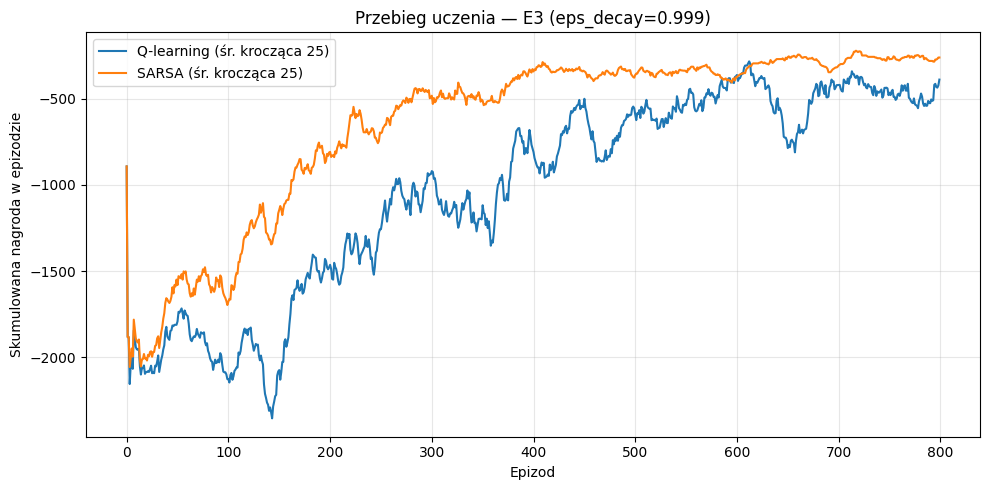

In [7]:
eps_995 = 1.0; eps_999 = 1.0
for ep in range(800):
    eps_995 = max(0.05, eps_995 * 0.995)
    eps_999 = max(0.05, eps_999 * 0.999)
print(f"epsilon po 800 epizodach: decay=0.995 -> {eps_995:.3f}, decay=0.999 -> {eps_999:.3f}")

e3 = run_experiment("E3 (eps_decay=0.999)", epsilon_decay=0.999)
print_metrics(e3)
plot_learning(e3)

--- Polityka zachłanna: Q-learning (E3 (eps_decay=0.999)) ---
 →  →  →  →  ↓  →  →  →  ↓  →  →  ↓ 
 →  →  →  →  →  →  →  ↓  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



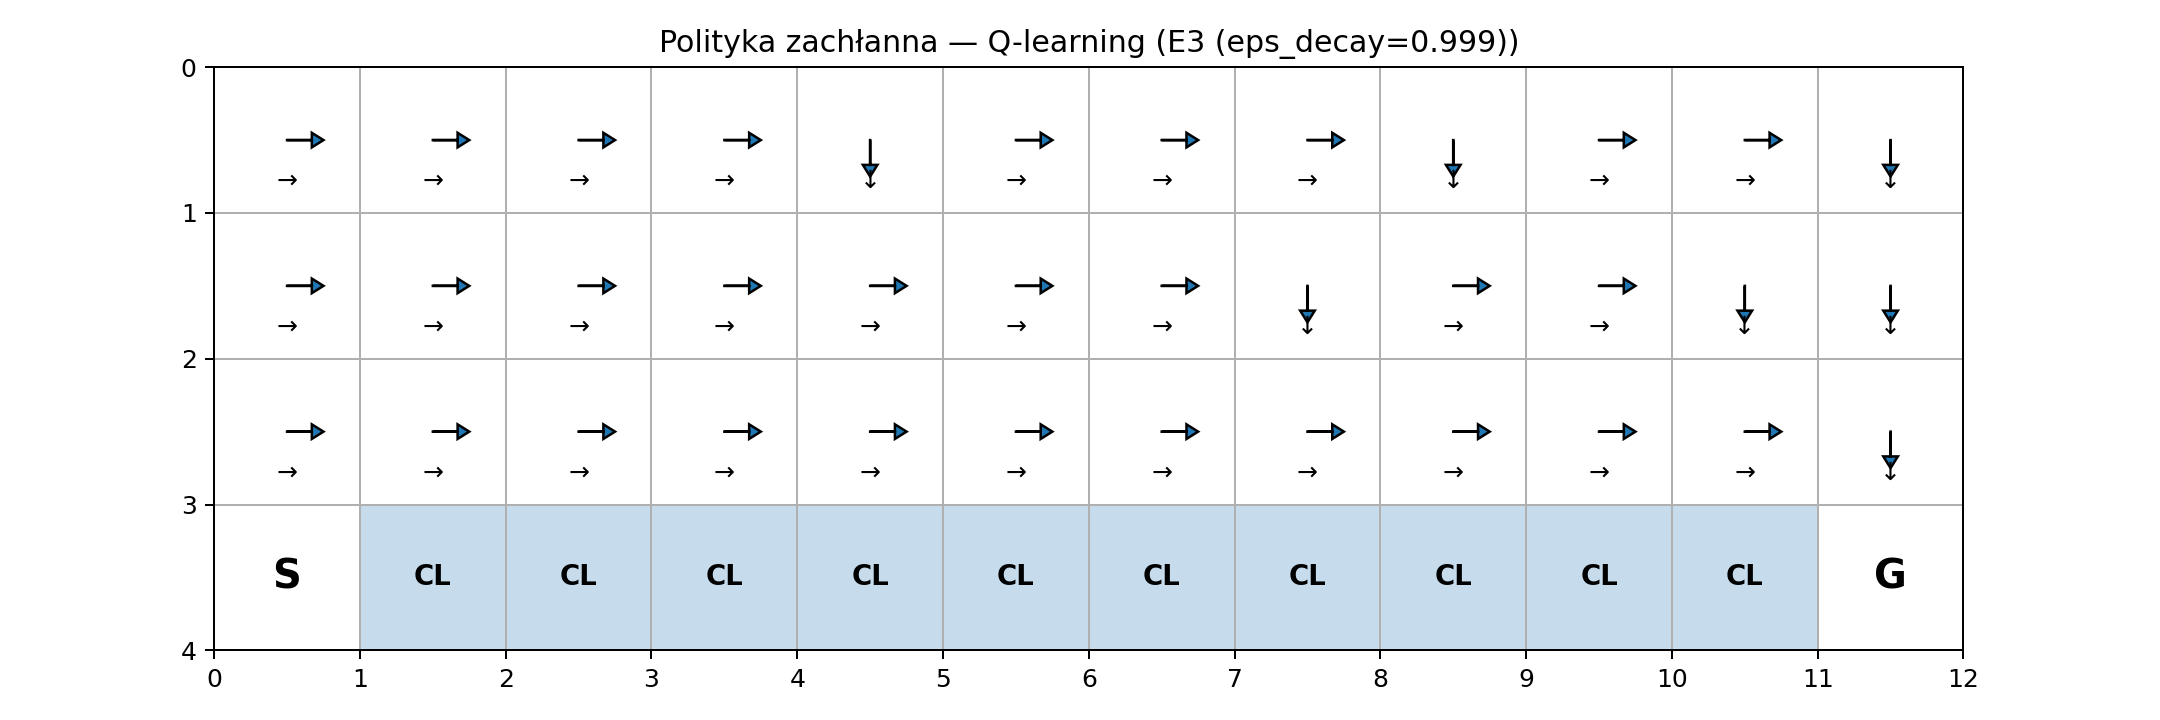

--- Polityka zachłanna: SARSA (E3 (eps_decay=0.999)) ---
 ↑  ←  ←  ←  ←  →  →  →  →  →  →  ↓ 
 ↑  ←  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



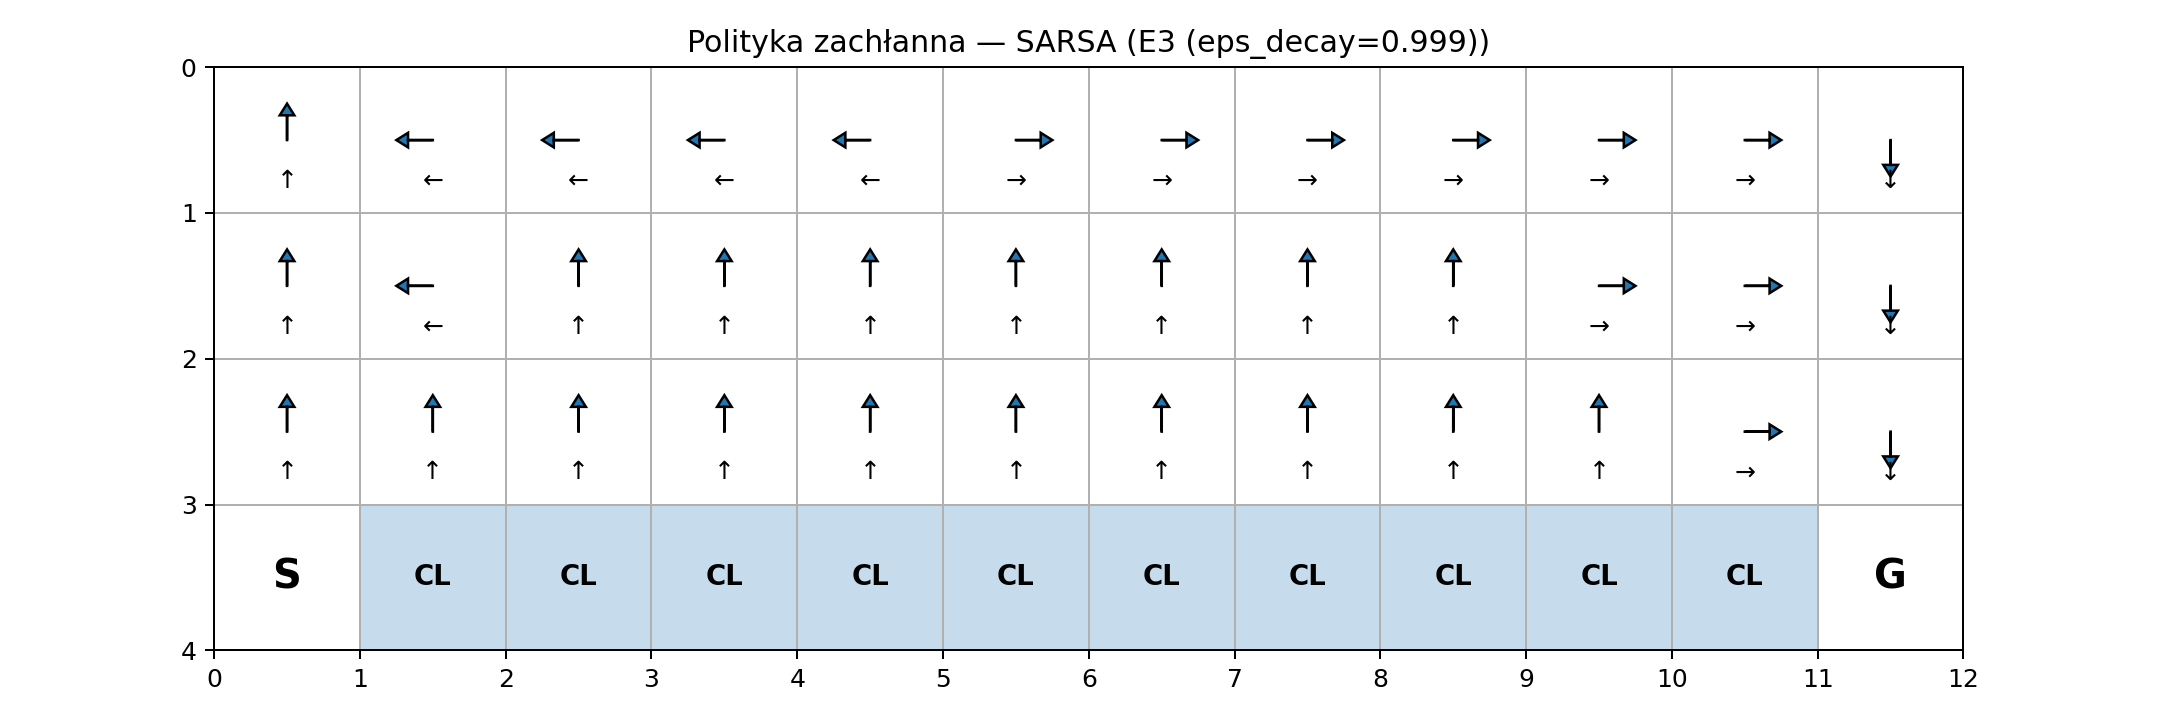

In [8]:
show_policies(e3)
all_rows += metrics_rows(e3, "Q-learning odporny na długą eksplorację; SARSA bez spójnej polityki (0% sukcesów)")

### Interpretacja E3

- Krzywe uczenia leżą **wyraźnie niżej** niż w E1 (Q-learning: śr. −443 w ostatnich 100 epizodach!) —
  przy ε ≈ 0.45 agent niemal co drugą akcję losuje, więc nieustannie wpada do klifu.
- **Q-learning mimo to nauczył się optymalnej trasy** (eval −13, 100%): jako metoda off-policy uczy się wartości
  polityki zachłannej **niezależnie od tego, jak chaotycznie się porusza** w trakcie treningu.
- **SARSA poniosła porażkę** (0% sukcesów, −200): uczyła się wartości polityki niemal losowej, dla której
  okolice klifu są skrajnie niebezpieczne. Jej finalna polityka „ucieka" w górę i w lewo planszy
  (lewa kolumna strzałek ↑ zapętla agenta przy górnej krawędzi) i nigdy nie skręca do celu.
- Odpowiedź na pytanie pomocnicze: **wolniejszy zanik ε nie poprawił finalnej polityki — wręcz ją zepsuł
  w przypadku SARSY**. Dla metod on-policy ε musi zmaleć przed końcem treningu, żeby wyuczone wartości
  odpowiadały polityce zbliżonej do zachłannej. Wolny zanik ε wymagałby tu odpowiednio większej liczby epizodów.

## 7. Eksperyment E4 — słabsza kara za klif: `cliff_penalty = -10`

Pytanie pomocnicze: *jak zmieniają się wyniki po zmniejszeniu kary za klif?*
Kara spada ze −100 do −10, czyli upadek kosztuje tyle, co 10 zwykłych kroków.
**Uwaga:** nagrody z E4 nie są wprost porównywalne liczbowo z pozostałymi eksperymentami (inna skala kar).

Q-learning  | eval: śr. nagroda   -13.00 (std 0.00), śr. kroki  13.00, success 100% | trening (ost. 100 ep.): śr.   -15.71, std 5.86
SARSA       | eval: śr. nagroda   -17.00 (std 0.00), śr. kroki  17.00, success 100% | trening (ost. 100 ep.): śr.   -17.79, std 1.44


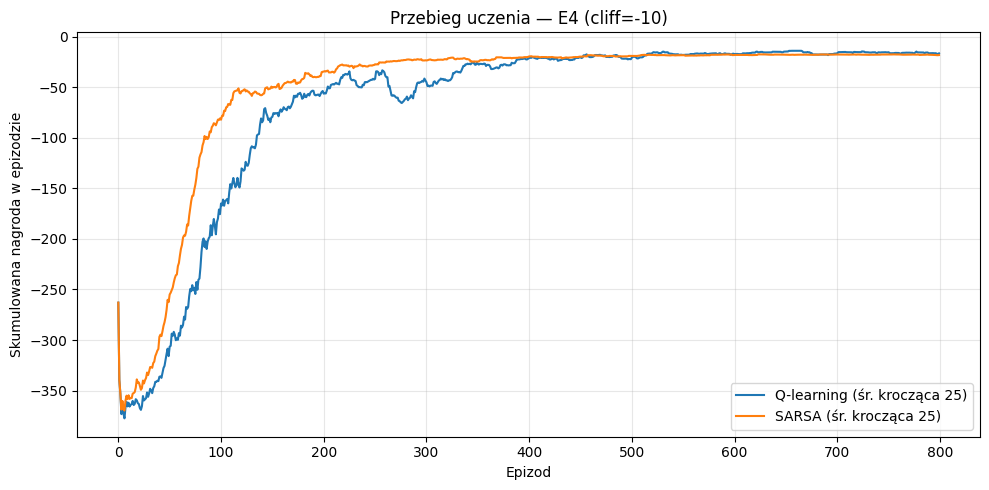

In [9]:
e4 = run_experiment("E4 (cliff=-10)", cliff_penalty=-10.0)
print_metrics(e4)
plot_learning(e4)

--- Polityka zachłanna: Q-learning (E4 (cliff=-10)) ---
 ←  ←  →  ↓  ←  ↓  →  →  ↓  ↓  →  ↓ 
 →  ↓  →  ←  →  →  →  ↓  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



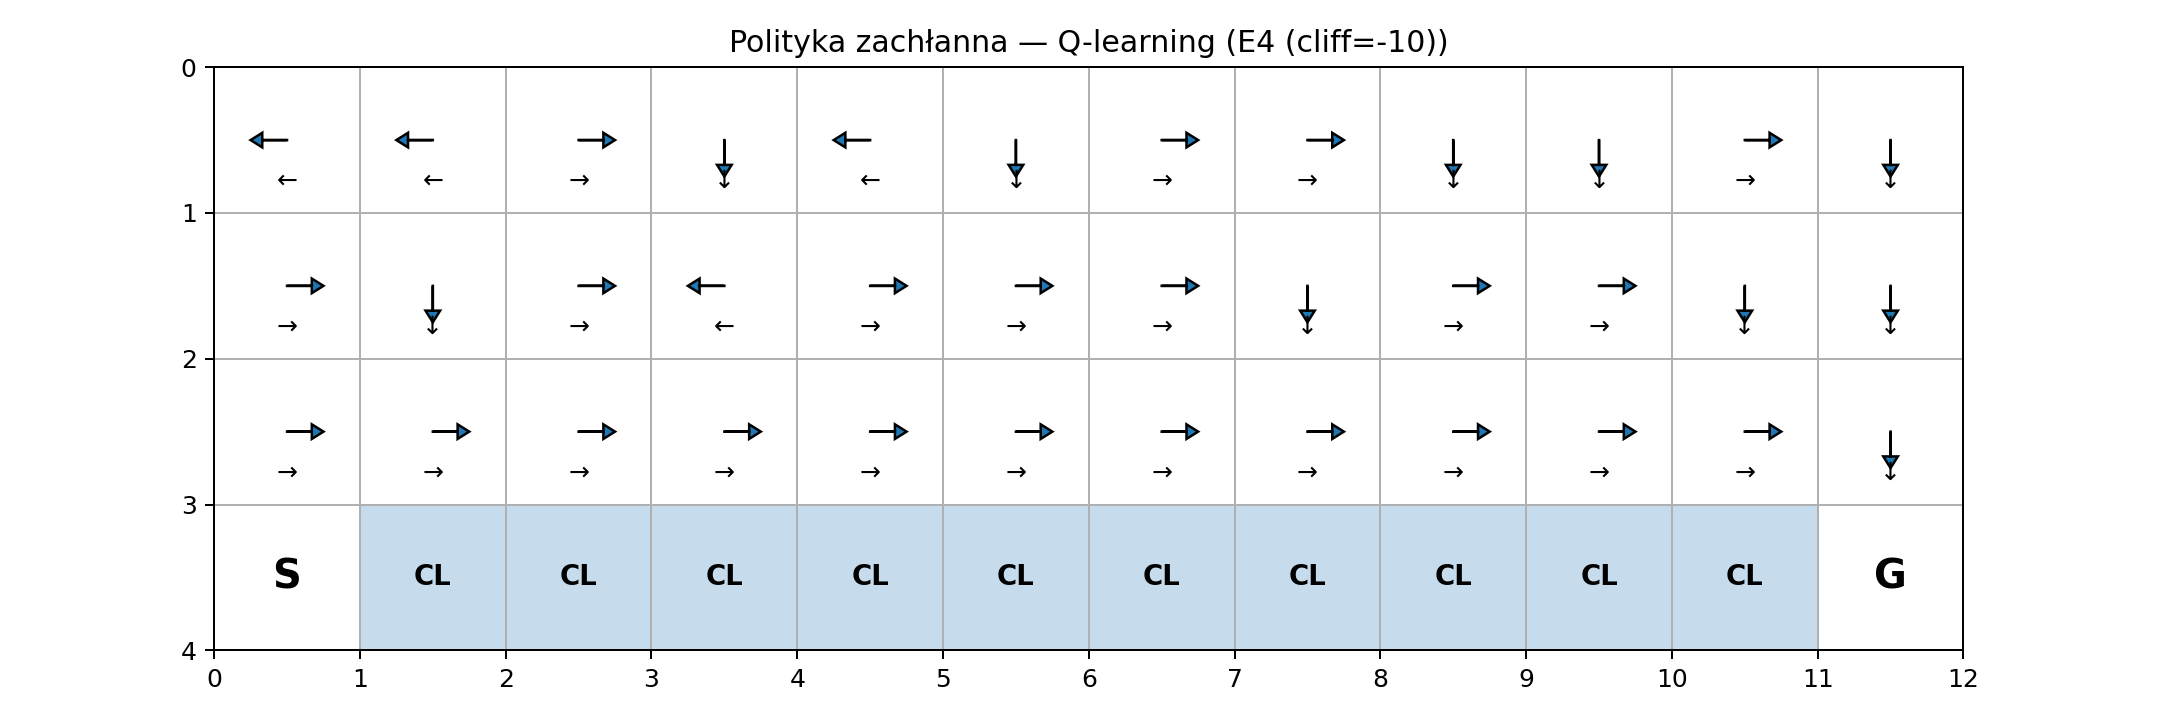

--- Polityka zachłanna: SARSA (E4 (cliff=-10)) ---
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



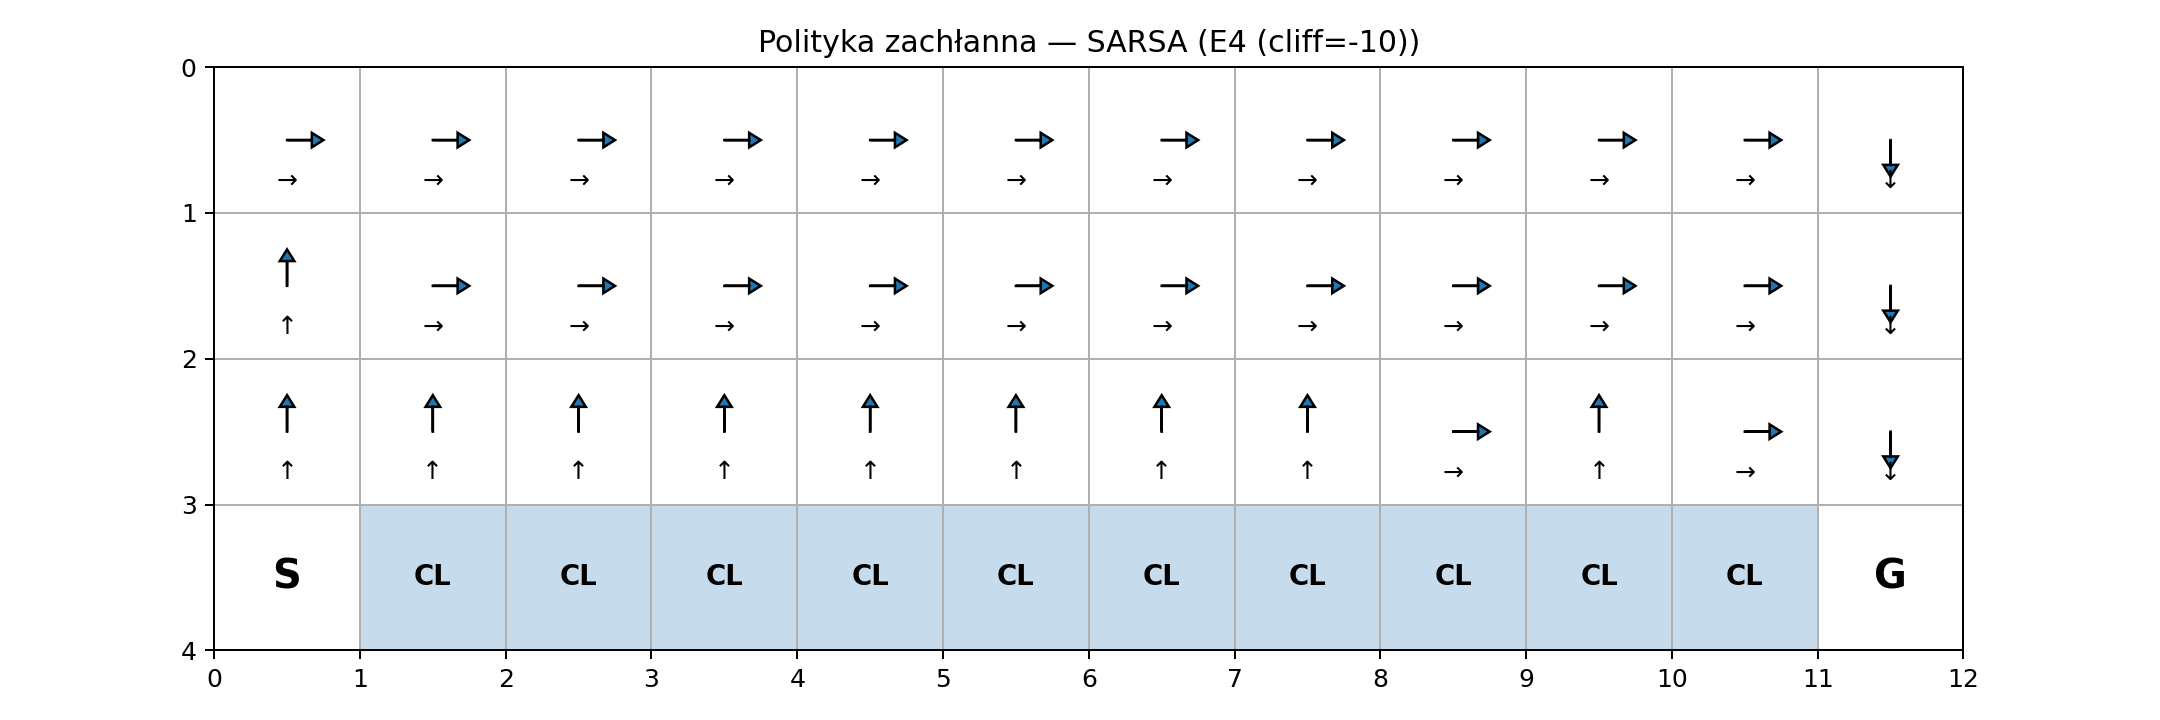

In [10]:
show_policies(e4)
all_rows += metrics_rows(e4, "Upadki tanie: krzywe gładkie, Q-learning w treningu lepszy od SARSY; przewaga bezpiecznej trasy znika")

### Interpretacja E4

- Przy karze −10 upadek przestaje być katastrofą — krzywe uczenia rosną szybciej, są **gładkie** i leżą blisko
  siebie (std nagród treningowych spadło do 5.9 dla Q-learninga i 1.4 dla SARSY — najniższe wartości w całym
  badaniu).
- **Przewaga treningowa SARSY znika, a nawet się odwraca**: Q-learning osiąga w ostatnich 100 epizodach średnią
  **−15.7**, lepszą niż SARSA (**−17.8**). Skoro upadek kosztuje tyle, co 10 kroków, ryzykowna krótka trasa
  Q-learninga opłaca się nawet z eksploracją.
- Finalna trasa SARSY w tym przebiegu pozostała bezpieczna (górny wiersz, −17), choć jej środkowy wiersz
  strzałek prowadzi już wzdłuż planszy, a nie „uciekając" do góry jak w E1 — wyceny pól bliżej klifu wyraźnie
  wzrosły.
- Wniosek praktyczny: to **funkcja nagrody steruje tym, jak „ostrożny" jest agent** — rozróżnienie
  zachłanny/bezpieczny ma znaczenie tylko wtedy, gdy błąd jest naprawdę kosztowny.

## 8. Eksperyment E5 — więcej epizodów: `episodes = 2000`

Pytanie pomocnicze: *czy większa liczba epizodów zawsze poprawia wyniki? Kiedy pojawia się efekt malejących
korzyści?*

Q-learning  | eval: śr. nagroda   -13.00 (std 0.00), śr. kroki  13.00, success 100% | trening (ost. 100 ep.): śr.   -35.98, std 50.09
SARSA       | eval: śr. nagroda   -17.00 (std 0.00), śr. kroki  17.00, success 100% | trening (ost. 100 ep.): śr.   -21.01, std 17.29


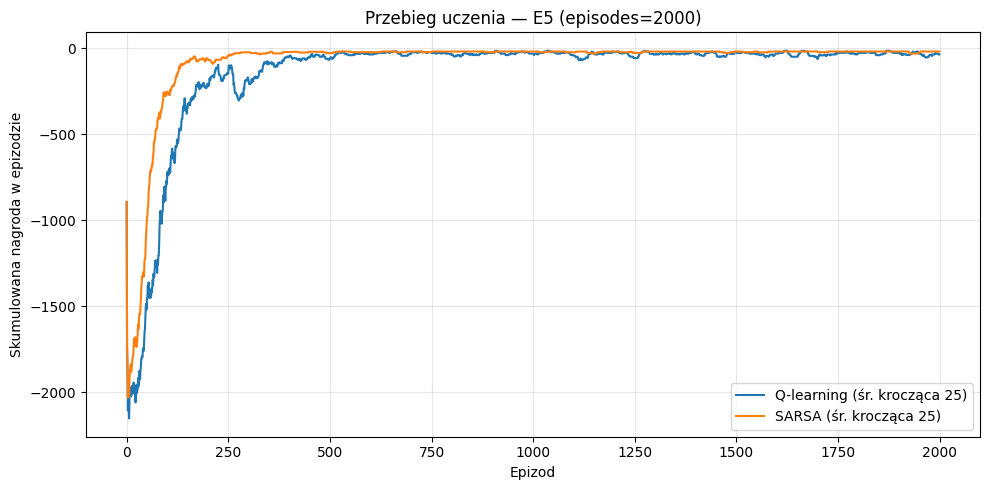

In [11]:
e5 = run_experiment("E5 (episodes=2000)", episodes=2000)
print_metrics(e5)
plot_learning(e5)

--- Polityka zachłanna: Q-learning (E5 (episodes=2000)) ---
 →  →  →  ↓  ↑  ↓  ↓  →  →  ↓  →  ↓ 
 ↓  →  ↓  ↓  ↓  →  ↓  →  →  ↓  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



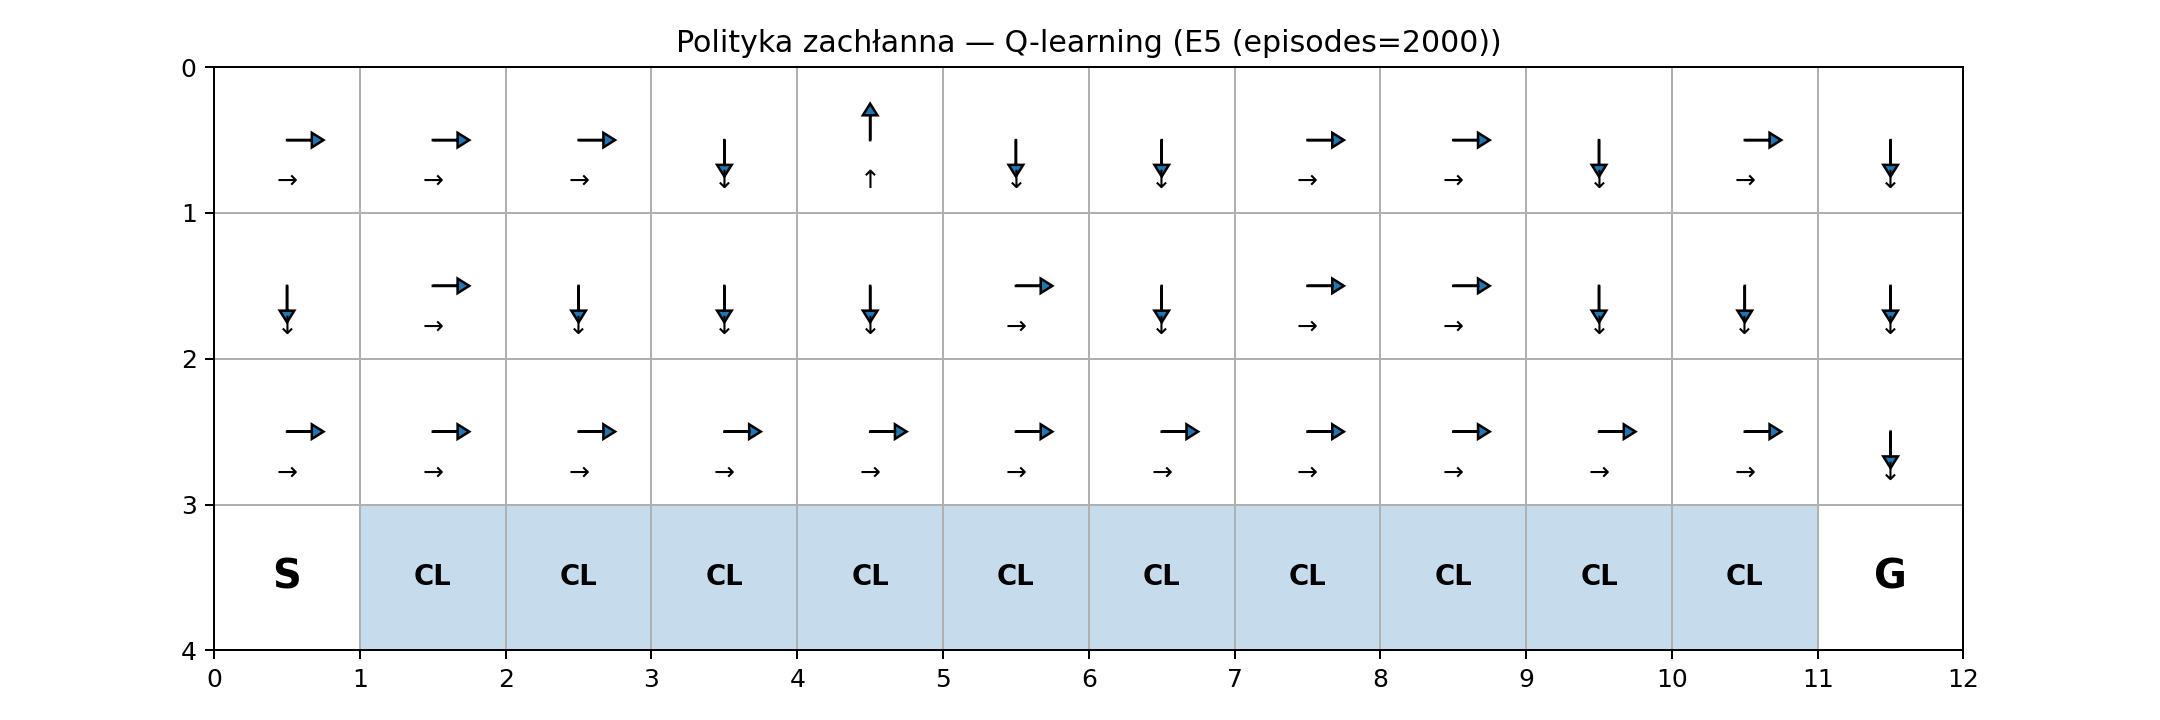

--- Polityka zachłanna: SARSA (E5 (episodes=2000)) ---
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 



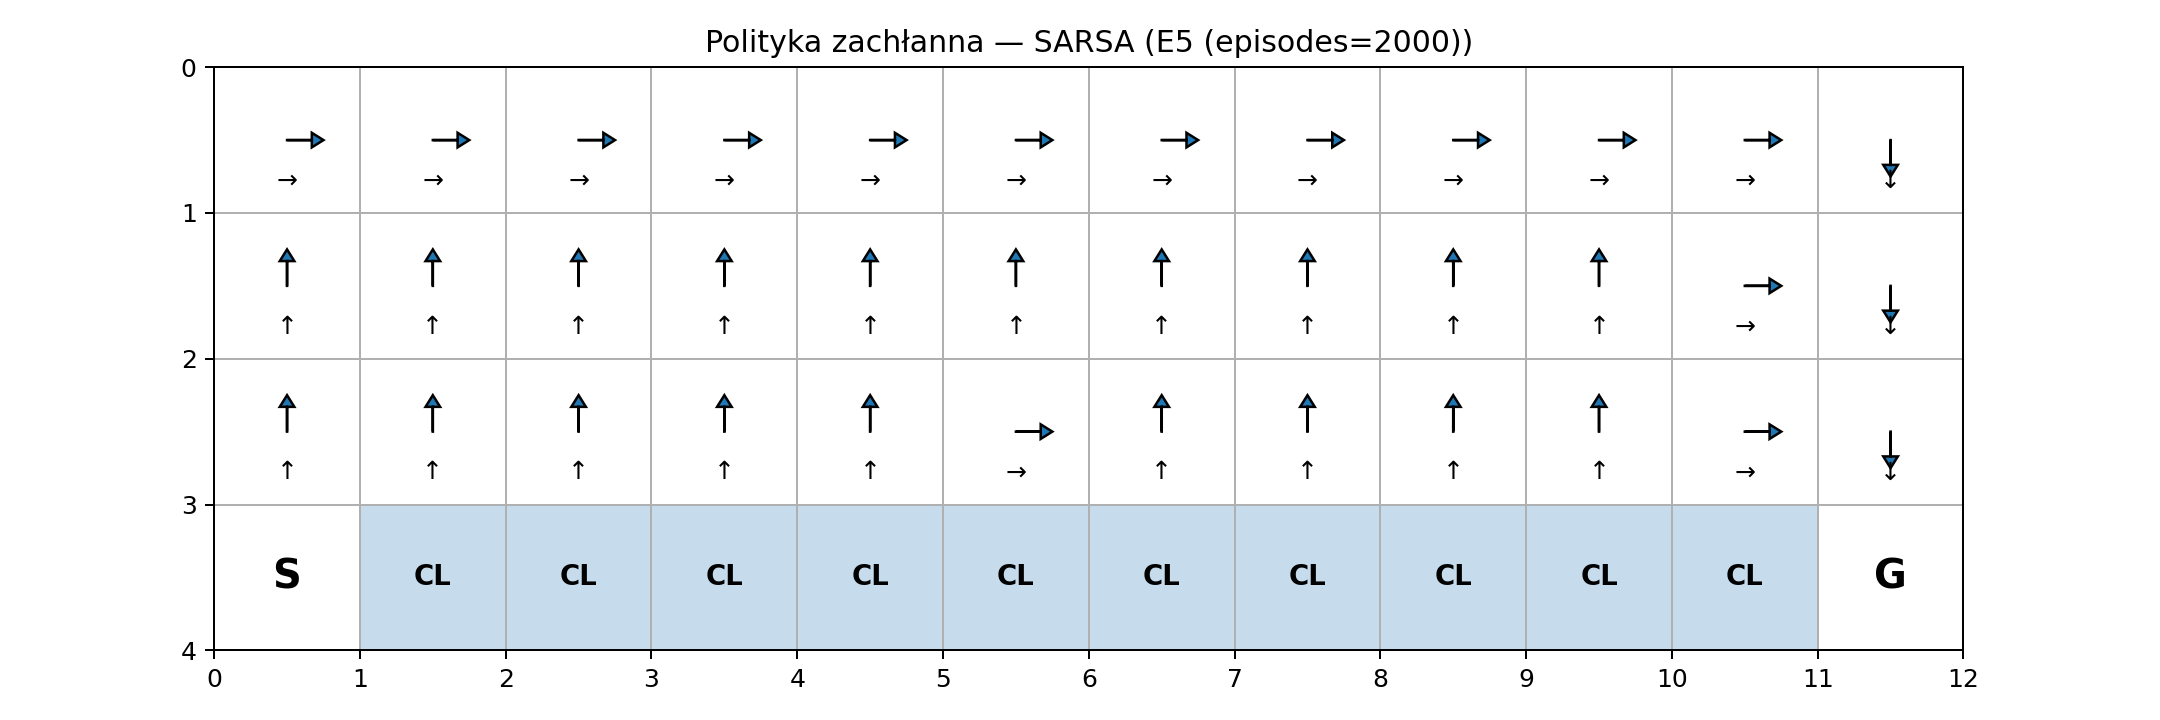

In [12]:
show_policies(e5)
all_rows += metrics_rows(e5, "Po ~400 epizodach plateau — dalszy trening nie poprawia polityki (malejące korzyści)")

### Interpretacja E5

- Krzywe stabilizują się w okolicach epizodu 300–400 i przez kolejne ~1600 epizodów oscylują wokół tego samego
  poziomu — **klasyczny efekt malejących korzyści**. Finalne metryki ewaluacji są praktycznie identyczne jak w E1.
- Resztkowe wahania krzywej Q-learninga to skutek stałego ε_min = 0.05: agent co jakiś czas losowo wpada do klifu
  (jego trasa biegnie przy samej krawędzi), czego SARSA unika — stąd w ostatnich 100 epizodach Q-learning ma
  średnią −36.0 przy std 50.1, a SARSA −21.0 przy std 17.3.
- Dłuższy trening ma sens, dopóki polityka się zmienia; tutaj tablica Q (48×4) nasyca się bardzo szybko.

## 9. Zbiorcza tabela eksperymentów

In [13]:
df = pd.DataFrame(all_rows)
df.to_csv(OUT / "tabela_eksperymentow.csv", index=False, encoding="utf-8-sig")
df

,Eksperyment,Algorytm,alpha,gamma,eps_decay,episodes,cliff_penalty,Śr. nagroda (eval),Śr. kroki (eval),Śr. nagroda trening (ost.100),Std trening (ost.100),Wniosek
0,E1,Q-learning,0.1,0.95,0.995,800,-100.0,-13.0,13.0,-25.61,33.86,Q-learning: trasa przy klifie; SARSA: trasa be...
1,E1,SARSA,0.1,0.95,0.995,800,-100.0,-17.0,17.0,-18.87,9.95,Q-learning: trasa przy klifie; SARSA: trasa be...
2,E2,Q-learning,0.5,0.95,0.995,800,-100.0,-13.0,13.0,-32.12,43.36,Q-learning nadal optymalny; SARSA niestabilna ...
3,E2,SARSA,0.5,0.95,0.995,800,-100.0,-200.0,200.0,-200.99,9.85,Q-learning nadal optymalny; SARSA niestabilna ...
4,E3,Q-learning,0.1,0.95,0.999,800,-100.0,-13.0,13.0,-442.89,412.86,Q-learning odporny na długą eksplorację; SARSA...
5,E3,SARSA,0.1,0.95,0.999,800,-100.0,-200.0,200.0,-258.10,111.21,Q-learning odporny na długą eksplorację; SARSA...
6,E4,Q-learning,0.1,0.95,0.995,800,-10.0,-13.0,13.0,-15.71,5.86,"Upadki tanie: krzywe gładkie, Q-learning w tre..."
7,E4,SARSA,0.1,0.95,0.995,800,-10.0,-17.0,17.0,-17.79,1.44,"Upadki tanie: krzywe gładkie, Q-learning w tre..."
8,E5,Q-learning,0.1,0.95,0.995,2000,-100.0,-13.0,13.0,-35.98,50.09,Po ~400 epizodach plateau — dalszy trening nie...
9,E5,SARSA,0.1,0.95,0.995,2000,-100.0,-17.0,17.0,-21.01,17.29,Po ~400 epizodach plateau — dalszy trening nie...


## 10. Porównawcze wykresy przebiegu uczenia

Zestawienie krzywych uczenia z wszystkich eksperymentów osobno dla każdego algorytmu — pozwala bezpośrednio
ocenić wpływ parametrów na szybkość uczenia i stabilność.

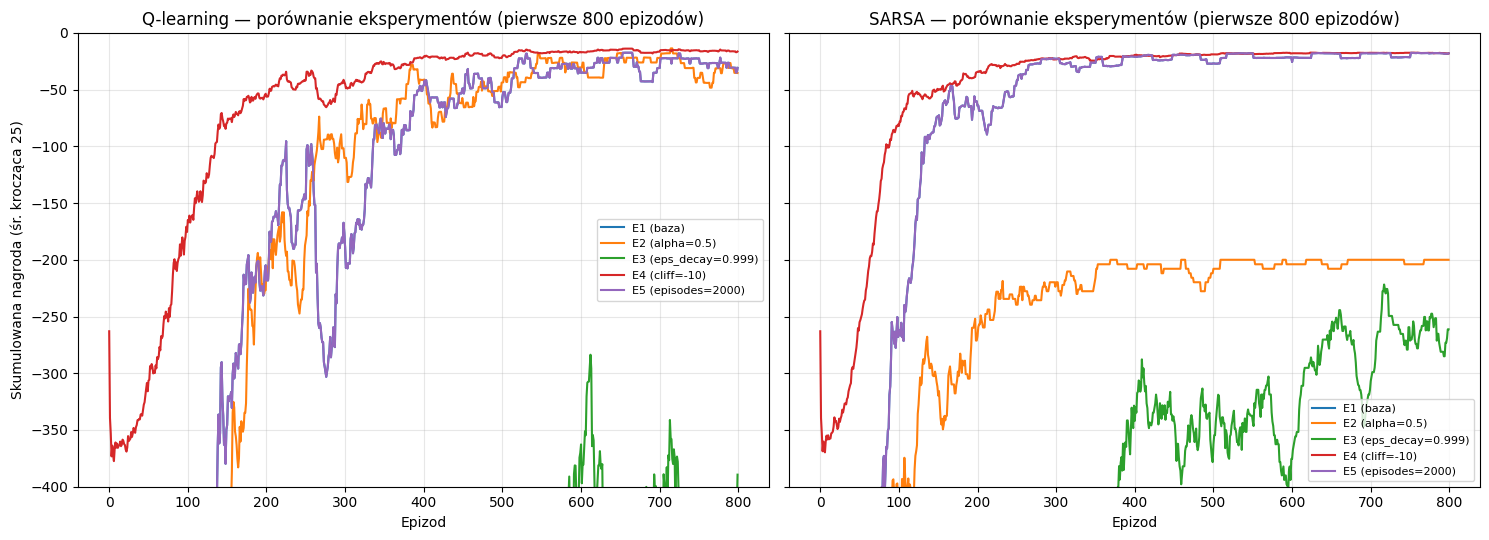

In [14]:
experiments = [e1, e2, e3, e4, e5]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, algo in zip(axes, ["Q-learning", "SARSA"]):
    for exp in experiments:
        ma = rl.moving_average(exp["results"][algo]["episode_rewards"], 25)
        ax.plot(ma[:800], label=exp["name"])
    ax.set_title(f"{algo} — porównanie eksperymentów (pierwsze 800 epizodów)")
    ax.set_xlabel("Epizod")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Skumulowana nagroda (śr. krocząca 25)")
axes[0].set_ylim(-400, 0)
plt.tight_layout()
plt.savefig(OUT / "porownanie_wszystkich.png", dpi=150)
plt.show()

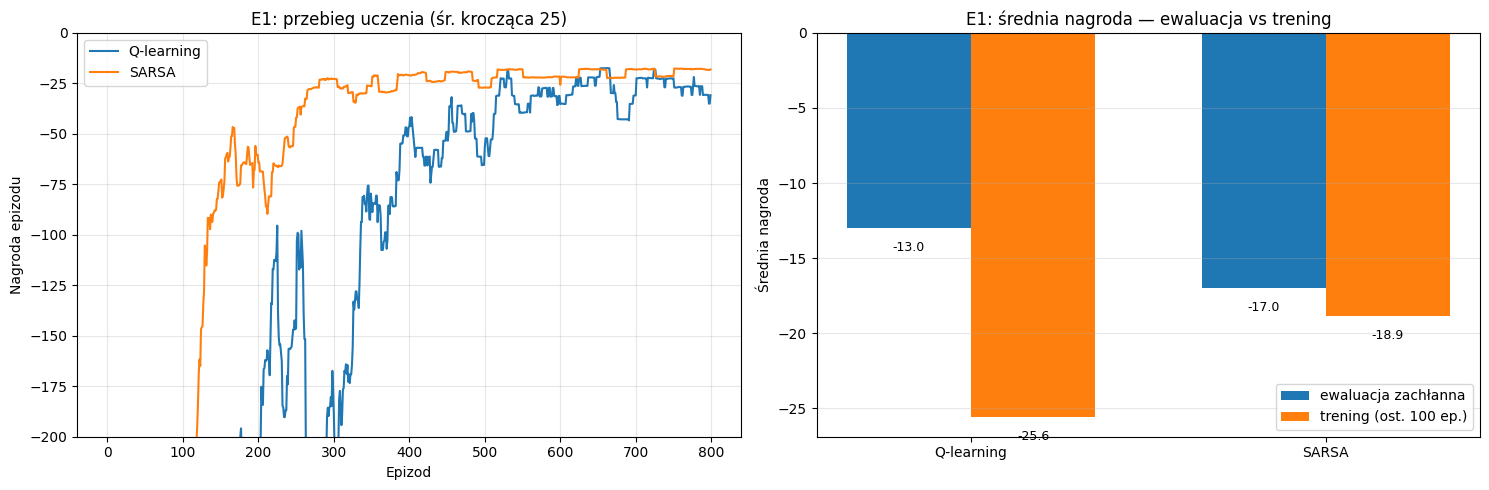

In [15]:
# Bezpośrednie porównanie Q-learning vs SARSA na konfiguracji bazowej (E1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ma_q = rl.moving_average(e1["results"]["Q-learning"]["episode_rewards"], 25)
ma_s = rl.moving_average(e1["results"]["SARSA"]["episode_rewards"], 25)
axes[0].plot(ma_q, label="Q-learning")
axes[0].plot(ma_s, label="SARSA")
axes[0].set_title("E1: przebieg uczenia (śr. krocząca 25)")
axes[0].set_xlabel("Epizod"); axes[0].set_ylabel("Nagroda epizodu")
axes[0].set_ylim(-200, 0); axes[0].legend(); axes[0].grid(True, alpha=0.3)

labels = ["Q-learning", "SARSA"]
eval_r = [e1["metrics"][a]["mean_reward"] for a in labels]
train_r = [e1["metrics"][a]["train_mean_last100"] for a in labels]
x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, eval_r, w, label="ewaluacja zachłanna")
axes[1].bar(x + w/2, train_r, w, label="trening (ost. 100 ep.)")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title("E1: średnia nagroda — ewaluacja vs trening")
axes[1].set_ylabel("Średnia nagroda"); axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")
for i, (ev, tr) in enumerate(zip(eval_r, train_r)):
    axes[1].text(i - w/2, ev - 1.5, f"{ev:.1f}", ha="center", fontsize=9)
    axes[1].text(i + w/2, tr - 1.5, f"{tr:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "porownanie_e1.png", dpi=150)
plt.show()

## 11. Porównanie finalnych polityk i metryk

**Kształt polityk:**

- **Q-learning we wszystkich pięciu eksperymentach** znalazł tę samą optymalną trasę: krok w górę, 11 kroków
  w prawo **wzdłuż samej krawędzi klifu**, krok w dół do celu (13 kroków, nagroda −13, 100% sukcesów).
  Finalna polityka okazała się całkowicie niewrażliwa na badane zmiany parametrów.
- **SARSA** w E1, E4 i E5 wybiera trasę **najwyższym wierszem planszy** (17 kroków, nagroda −17) — dłuższą,
  ale maksymalnie odsuniętą od przepaści. W E2 (`alpha=0.5`) i E3 (`eps_decay=0.999`) jej finalna polityka
  jest **niespójna i nie dociera do celu** (0% sukcesów, nagroda −200) — wartości Q odzwierciedlają politykę
  silnie eksploracyjną, a nie zachłanną.

**Metryki:**

- **Ewaluacja zachłanna** (ε=0, środowisko deterministyczne → std = 0): Q-learning wygrywa we wszystkich
  eksperymentach (−13 i 13 kroków). SARSA tam, gdzie zbiega (E1/E4/E5), osiąga −17 i 17 kroków.
- **Trening** (z eksploracją, ostatnie 100 epizodów): przy dużej karze za klif (E1: −18.9 vs −25.6,
  E5: −21.0 vs −36.0) **SARSA ma wyższą średnią nagrodę i 2–3× mniejsze odchylenie** — jest stabilniejsza
  i bezpieczniejsza, bo losowy ruch eksploracyjny rzadko kończy się u niej upadkiem.
- Przewaga SARSY znika, gdy kara za błąd jest mała (E4: Q-learning −15.7 vs SARSA −17.8) — ryzykowna krótka
  trasa przestaje być karana.

## 12. Wnioski końcowe

1. **Szybkość uczenia:** oba algorytmy stabilizują się w podobnym czasie (~300–400 epizodów przy ustawieniach
   bazowych). Zwiększenie `alpha` do 0.5 (E2) przyspiesza początkową fazę uczenia, ale zwiększa wariancję
   przebiegu — i okazało się zabójcze dla SARSY. Wolniejszy zanik ε (E3) drastycznie wydłuża fazę niskich nagród.
2. **Stabilność (w trakcie treningu):** przy domyślnej karze −100 stabilniejsza jest **SARSA** — jej krzywa leży
   wyżej i ma 2–3× mniejsze odchylenie (E1: std 10.0 vs 33.9), bo unika pól, na których eksploracja jest
   kosztowna. Krzywa Q-learninga do końca treningu wykazuje „zęby" spowodowane losowymi upadkami z klifu przy
   ε_min = 0.05.
3. **Jakość i odporność finalnej polityki:** tu zdecydowanie wygrywa **Q-learning** — we wszystkich pięciu
   eksperymentach znalazł trasę optymalną (−13). Jako metoda off-policy oddziela to, *czego się uczy*
   (politykę zachłanną), od tego, *jak się porusza*. Finalna polityka SARSY okazała się **wrażliwa na
   hiperparametry**: przy `alpha=0.5` (E2) i przy wolnym zaniku ε (E3) w ogóle nie docierała do celu,
   bo wyuczone wartości Q odpowiadały polityce eksploracyjnej, a nie zachłannej.
4. **Kiedy wariant zachłanny (Q-learning)?** Gdy finalna polityka będzie wykonywana **bez eksploracji**
   w przewidywalnym środowisku, a liczy się optymalność i odporność na dobór parametrów — ryzyko treningowe
   nie przenosi się wtedy na produkcję.
5. **Kiedy wariant bezpieczniejszy (SARSA)?** Gdy agent **uczy się w środowisku docelowym** i koszty błędów
   ponosi w trakcie działania (robotyka, systemy fizyczne), albo gdy w działaniu pozostaje element losowości.
   Wymaga jednak staranniejszego strojenia: umiarkowanej `alpha` i ε, które zdąży zmaleć przed końcem treningu.
6. **Funkcja nagrody kształtuje ostrożność agenta** (E4): przy karze −10 przewaga treningowa SARSY znika
   (Q-learning −15.7 vs SARSA −17.8), a krzywe obu metod stają się gładkie. Wysokość kar trzeba dobierać
   świadomie do realnych kosztów błędów.
7. **Więcej epizodów nie zawsze pomaga** (E5): po nasyceniu tablicy Q (~400 epizodów) dalszy trening daje
   malejące korzyści — finalne metryki po 2000 epizodów są identyczne jak po 800.

### Odpowiedzi na pytania pomocnicze

- **Jak wpływa zwiększenie alpha?** Szybsza propagacja wiedzy i szybszy start, ale gwałtowniejsze nadpisywanie Q.
  Q-learning to zniósł; SARSA przy `alpha=0.5` utraciła spójną politykę finalną (0% sukcesów), bo szum
  eksploracji wchodzi u niej bezpośrednio do celu aktualizacji (E2).
- **Czy wolniejsze zmniejszanie epsilon poprawia finalną politykę?** Nie — w tym małym, deterministycznym
  środowisku ją pogorszyło: Q-learning pozostał optymalny, ale SARSA przy ε ≈ 0.45 na końcu treningu nauczyła
  się wartości polityki niemal losowej i jej polityka zachłanna nie dociera do celu (E3). Wolny zanik ε wymaga
  proporcjonalnie dłuższego treningu.
- **Który algorytm częściej wybiera trasę blisko klifu?** **Q-learning** — jako algorytm off-policy uczy się
  wartości polityki optymalnej i ignoruje ryzyko własnej eksploracji; SARSA (on-policy) wlicza to ryzyko
  w wartości Q i odsuwa trasę od krawędzi (E1, E5).
- **Czy większa liczba epizodów zawsze poprawia wyniki?** Nie — poprawia tylko do momentu nasycenia
  (~400 epizodów); potem występuje efekt malejących korzyści (E5).
- **Jak zmieniają się wyniki po zmniejszeniu kary za klif?** Krzywe uczenia stają się gładsze i wyższe,
  przewaga „bezpiecznej" SARSY znika, a ryzykowna trasa przy krawędzi przestaje być karana w treningu (E4);
  większa kara działałaby odwrotnie — jeszcze mocniej odpychając SARSĘ od krawędzi i pogłębiając różnicę
  między algorytmami.